In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import interp1d
import matplotlib.ticker as ticker


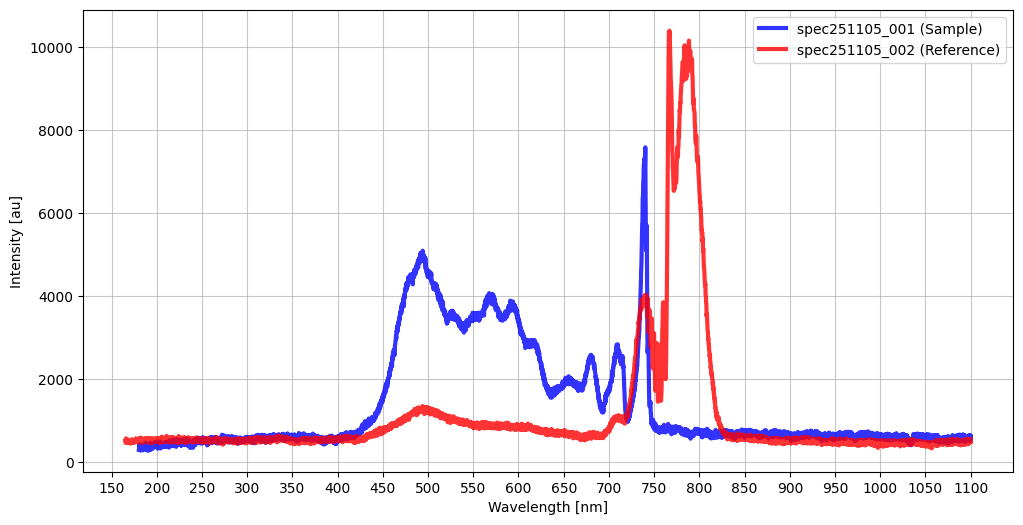

In [3]:
# Load data with pandas (skiprows=8 skips the header metadata)
df1 = pd.read_csv('spec251105_001.txt', sep=';', skiprows=8, decimal=',', names=['Wave', 'Sample', 'Dark', 'Ref', 'Corr'])
df2 = pd.read_csv('spec251105_002.txt', sep=';', skiprows=8, decimal=',', names=['Wave', 'Sample', 'Dark', 'Ref', 'Corr'])

# Simple Plot
plt.figure(figsize=(12, 6))
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(50))
plt.plot(df1['Wave'], df1['Sample'], label='spec251105_001 (Sample)', alpha=0.8, color='b', lw=3)
plt.plot(df2['Wave'], df2['Sample'], label='spec251105_002 (Reference)', alpha=0.8, color='r', lw=3)
plt.xlabel('Wavelength [nm]')
plt.ylabel('Intensity [au]')
#plt.title('Spectral Raw Data')
plt.legend()
plt.grid(True, alpha=0.7)
plt.savefig('di0.png')
pd.concat([df1[['Wave', 'Sample']], df2[['Sample']]], axis=1).to_csv('spectral_data.csv', index=False, header=['Wavelength_nm', 'Sample_Intensity', 'Reference_Intensity'])
plt.show()

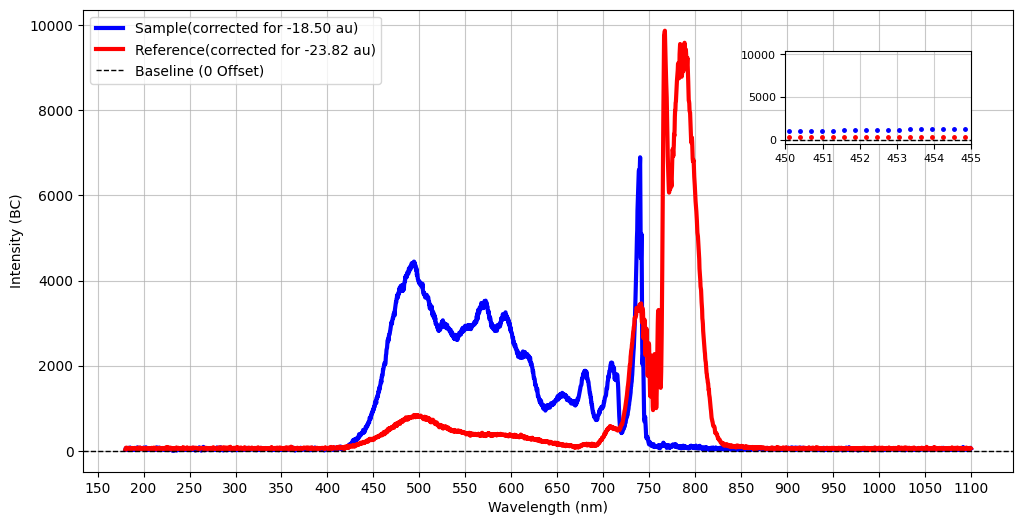

In [68]:
# 1. Load Data
cfg = {'sep': ';', 'skiprows': 8, 'decimal': ',', 'names': ['Wavelength', 'Sample', 'Dark', 'Ref', 'Intensity']}
df1, df2 = pd.read_csv('spec251105_001.txt', **cfg), pd.read_csv('spec251105_002.txt', **cfg)

# --- SIMPLE BASELINE & ALIGNMENT ---
df1['Int_BC'] = df1['Intensity'] - df1['Intensity'].min()
df2_aligned = np.interp(df1['Wavelength'], df2['Wavelength'], df2['Intensity'] - df2['Intensity'].min())

# 2. Target Interpolation
targets = [440, 469, 478, 493, 528, 556, 570, 594, 600, 619, 650, 657, 680, 698, 709]
y_sample = np.interp(targets, df1['Wavelength'], df1['Int_BC'])
y_ref = np.interp(targets, df1['Wavelength'], df2_aligned)

# 3. Visualization
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(df1['Wavelength'], df1['Int_BC'], 'b', lw=3, label='Sample(corrected for -18.50 au)')
ax.plot(df1['Wavelength'], df2_aligned, 'r', lw=3, label='Reference(corrected for -23.82 au)')

# --- BASELINE MARKER ---
ax.axhline(0, color='black', linestyle='--', linewidth=1, label='Baseline (0 Offset)')

# Formatting
ax.set_xlabel('Wavelength (nm)'); ax.set_ylabel('Intensity (BC)')
ax.xaxis.set_major_locator(ticker.MultipleLocator(50))
ax.grid(True, alpha=0.7); ax.legend(loc='upper left')

# 4. Inset Plot
ax_ins = inset_axes(ax, width="20%", height="20%", loc='upper right', borderpad=3)
ax_ins.plot(df1['Wavelength'], df1['Int_BC'], 'b.', df1['Wavelength'], df2_aligned, 'r.', markersize=5)
ax_ins.axhline(0, color='black', linestyle='--', linewidth=1) # Baseline in inset
ax_ins.set_xlim(450, 455); ax_ins.grid(True, alpha=0.6); ax_ins.tick_params(labelsize=8)
plt.savefig('di1.png')
plt.show()

# Optional: Print Table
# print(pd.DataFrame({'Wavelength': targets, 'Sample': y_sample, 'Ref': y_ref}).round(2).to_string(index=False))

Table: Reflectance Analysis at Target Wavelengths
 Wavelength [nm]  Sample Intensity  Ref Intensity  Reflectance Ratio  Normalized Ratio [%]
             440          734.4655       353.5172             2.0776               29.3515
             469         3258.4333       628.3000             5.1861               73.2674
             478         4071.2241       789.1897             5.1587               72.8808
             493         4654.8966       929.2241             5.0094               70.7716
             528         3218.1379       704.2069             4.5699               64.5615
             556         3179.6897       586.8448             5.4183               76.5474
             570         3573.5862       516.8276             6.9145               97.6850
             594         3481.0345       517.7857             6.7229               94.9790
             600         3119.0167       501.2069             6.2230               87.9164
             619         2570.5862      

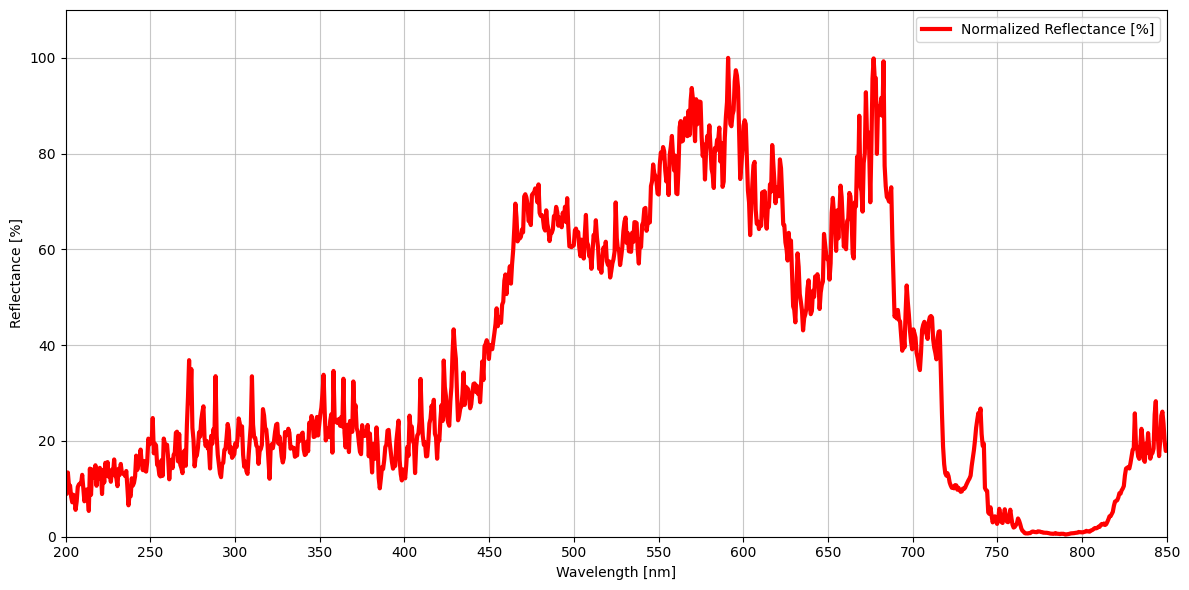

In [55]:
df1 = pd.read_csv('spec251105_001.txt', sep=';', skiprows=8, decimal=',', 
                 names=['Wavelength', 'Intensity', 'Dark', 'Ref', 'Corr'])
df2 = pd.read_csv('spec251105_002.txt', sep=';', skiprows=8, decimal=',', 
                 names=['Wavelength', 'Intensity', 'Dark', 'Ref', 'Corr'])

# 2. Baseline Correction
# Subtracting the minimum intensity to offset the noise floor to zero
df1['Int_BC'] = df1['Intensity'] - df1['Intensity'].min()
df2['Int_BC'] = df2['Intensity'] - df2['Intensity'].min()

# 3. Table Calculation (Target Wavelengths)
target_wavelengths = [440, 469, 478, 493, 528, 556, 570, 594, 600, 619, 650, 657, 680, 698, 709,739 ]

# Interpolate intensities for exact target matches
interp_sample_t = np.interp(target_wavelengths, df1['Wavelength'], df1['Int_BC'])
interp_ref_t = np.interp(target_wavelengths, df2['Wavelength'], df2['Int_BC'])

# Calculate reflectance ratios
raw_ratios_t = interp_sample_t / interp_ref_t
norm_ratios_t = raw_ratios_t / np.max(raw_ratios_t)

results_df = pd.DataFrame({
    'Wavelength [nm]': target_wavelengths,
    'Sample Intensity': interp_sample_t,
    'Ref Intensity': interp_ref_t,
    'Reflectance Ratio': raw_ratios_t,
    'Normalized Ratio [%]': norm_ratios_t * 100
})

# Display the Table
print("Table: Reflectance Analysis at Target Wavelengths")
print(results_df.round(4).to_string(index=False))

# 4. Continuous Reflectance Plot (400 to 800 nm)
common_wave = np.linspace(200, 850, 1000)
interp_s_p = np.interp(common_wave, df1['Wavelength'], df1['Int_BC'])
interp_r_p = np.interp(common_wave, df2['Wavelength'], df2['Int_BC'])

# Ratio calculation for the plot
raw_ratio_p = interp_s_p / interp_r_p
norm_ratio_pct = (raw_ratio_p / np.max(raw_ratio_p)) * 100

# 5. Plotting Normalized Reflectance Only
plt.figure(figsize=(12, 6))
plt.plot(common_wave, norm_ratio_pct, color='r', linewidth=3, label='Normalized Reflectance [%]')
#plt.title('Normalized Reflectance Ratio [%]')
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(50))
plt.xlabel('Wavelength [nm]')
plt.ylabel('Reflectance [%]')
plt.xlim(200, 850)
plt.ylim(0, 110)
plt.legend()
plt.grid(True, alpha=0.7)
plt.savefig('di2.png')
plt.tight_layout()
plt.show()

Table: Reflectance Ratio at target wavelengths
 Wavelength [nm]  Sample Intensity  Ref Intensity  Raw Ratio  Normalized Ratio  Normalized Ratio [%]
             440          734.4655       353.5172     2.0776            0.2935               29.3515
             448         1199.2759       421.1897     2.8474            0.4023               40.2263
             469         3258.4333       628.3000     5.1861            0.7327               73.2674
             478         4071.2241       789.1897     5.1587            0.7288               72.8808
             493         4654.8966       929.2241     5.0094            0.7077               70.7716
             528         3218.1379       704.2069     4.5699            0.6456               64.5615
             556         3179.6897       586.8448     5.4183            0.7655               76.5474
             570         3573.5862       516.8276     6.9145            0.9768               97.6850
             594         3481.0345       517

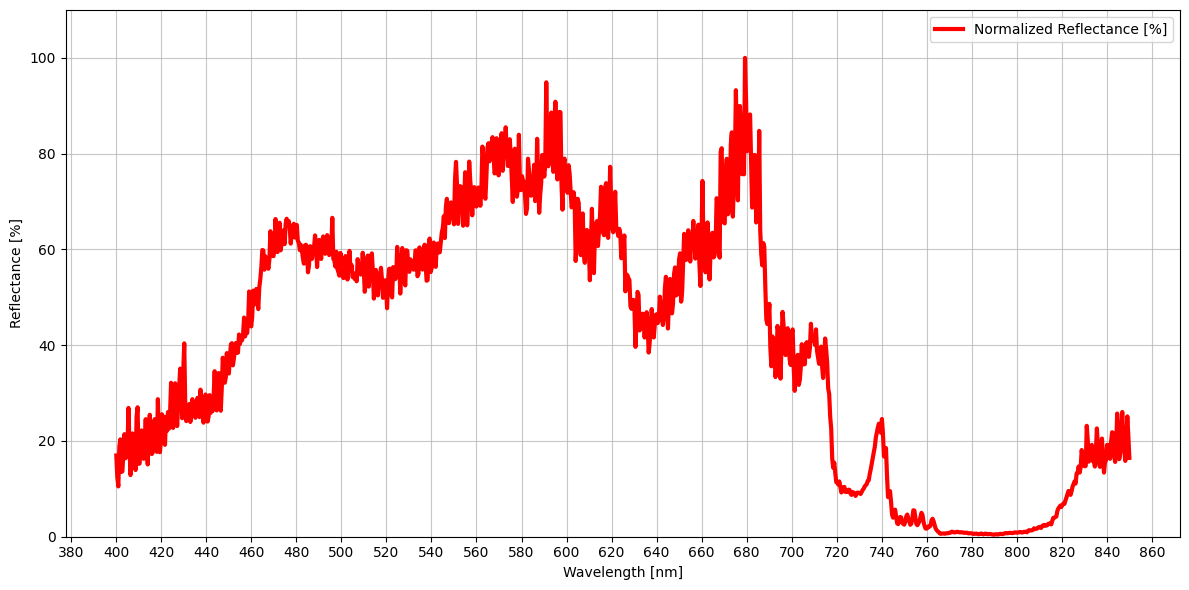

In [56]:
# 1. Load the data files
# Handling ';' separator, skipping 8 header rows, and comma decimals
df1 = pd.read_csv('spec251105_001.txt', sep=';', skiprows=8, decimal=',', 
                 names=['Wavelength', 'Intensity', 'Dark', 'Ref', 'Corr'])
df2 = pd.read_csv('spec251105_002.txt', sep=';', skiprows=8, decimal=',', 
                 names=['Wavelength', 'Intensity', 'Dark', 'Ref', 'Corr'])

# 2. Baseline Correction
# Offset the signal to zero by subtracting the minimum intensity
df1['Int_BC'] = df1['Intensity'] - df1['Intensity'].min()
df2['Int_BC'] = df2['Intensity'] - df2['Intensity'].min()

# 3. Table Calculation (Discrete Wavelengths)
target_wavelengths = [440,448, 469, 478, 493, 528, 556, 570, 594, 600, 619, 650, 657, 680, 698, 709, 739]
# Interpolate intensities at exact target wavelengths
interp_sample_t = np.interp(target_wavelengths, df1['Wavelength'], df1['Int_BC'])
interp_ref_t = np.interp(target_wavelengths, df2['Wavelength'], df2['Int_BC'])

# Calculate ratios
raw_ratios_t = interp_sample_t / interp_ref_t
norm_ratios_t = raw_ratios_t / np.max(raw_ratios_t)

# Create DataFrame with the new "Normalized Ratio" column
results_df = pd.DataFrame({
    'Wavelength [nm]': target_wavelengths,
    'Sample Intensity': interp_sample_t,
    'Ref Intensity': interp_ref_t,
    'Raw Ratio': raw_ratios_t,
    'Normalized Ratio': norm_ratios_t,         # New column requested
    'Normalized Ratio [%]': norm_ratios_t * 100
})

print("Table: Reflectance Ratio at target wavelengths")
print(results_df.round(4).to_string(index=False))
# 4. Continuous Ratio for Plotting (400 to 800 nm)
common_wave = np.linspace(400, 850, 1000)
interp_s_p = np.interp(common_wave, df1['Wavelength'], df1['Int_BC'])
interp_r_p = np.interp(common_wave, df2['Wavelength'], df2['Int_BC'])
raw_ratio_p = interp_s_p / interp_r_p
norm_ratio_pct = (raw_ratio_p / np.max(raw_ratio_p)) * 100

# 5. Reflectance Plot
plt.figure(figsize=(12, 6))
plt.plot(common_wave, norm_ratio_pct, color='r', linewidth=3, label='Normalized Reflectance [%]')
#plt.title('Normalized Reflectance Ratio [%]')
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(20))
plt.xlabel('Wavelength [nm]')
plt.ylabel('Reflectance [%]')
plt.ylim(0, 110)
plt.legend()
plt.grid(True, alpha=0.7)
plt.savefig('di3.png')
plt.tight_layout()
plt.show()

 Wavelength [nm]  Raw Ratio  Normalized Ratio  Normalized Ratio[%]
             440     2.0776            0.2935                29.35
             448     2.8474            0.4023                40.23
             469     5.1861            0.7327                73.27
             478     5.1587            0.7288                72.88
             493     5.0094            0.7077                70.77
             528     4.5699            0.6456                64.56
             556     5.4183            0.7655                76.55
             570     6.9145            0.9768                97.68
             594     6.7229            0.9498                94.98
             600     6.2230            0.8792                87.92
             619     5.3138            0.7507                75.07
             650     4.7860            0.6761                67.61
             657     4.9289            0.6963                69.63
             680     7.0783            1.0000               10

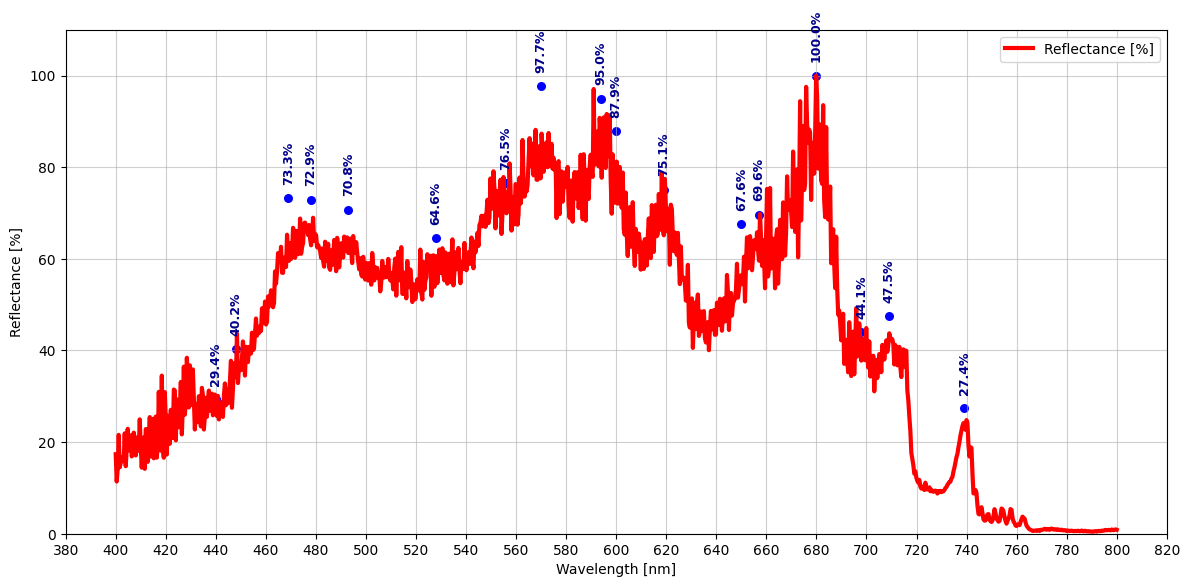

In [50]:
# 1. Load data
df1 = pd.read_csv('spec251105_001.txt', sep=';', skiprows=8, decimal=',', names=['W', 'I', 'D', 'R', 'C'])
df2 = pd.read_csv('spec251105_002.txt', sep=';', skiprows=8, decimal=',', names=['W', 'I', 'D', 'R', 'C'])

# 2. Baseline Correction & Interpolation
target_wavelengths = [440, 448, 469, 478, 493, 528, 556, 570, 594, 600, 619, 650, 657, 680, 698, 709, 739]
i_s = np.interp(target_wavelengths, df1['W'], df1['I'] - df1['I'].min())
i_r = np.interp(target_wavelengths, df2['W'], df2['I'] - df2['I'].min())

# 3. Ratio Calculation
raw_r = i_s / i_r
norm_r = raw_r / raw_r.max()
norm_pct = norm_r * 100

# 4. Create Table (Rounded Wavelengths)
results_df = pd.DataFrame({
    #'Peak Nr.': np.arange(len(target_wavelengths)) + 1,
    'Wavelength [nm]': np.round(target_wavelengths, 1),
    #'Sample Intensity': i_s,
    #'Ref Intensity': i_r,
    'Raw Ratio': np.round(raw_r, 4),
    'Normalized Ratio': np.round(norm_r, 4),
    'Normalized Ratio[%]': np.round(norm_pct, 2)
})

# 5. Continuous Data for Plotting
c_wave = np.linspace(400, 800, 1000)
c_ratio = np.interp(c_wave, df1['W'], df1['I'] - df1['I'].min()) / np.interp(c_wave, df2['W'], df2['I'] - df2['I'].min())
c_norm_pct = (c_ratio / c_ratio.max()) * 100

# 6. Plotting
plt.figure(figsize=(12, 6))
plt.plot(c_wave, c_norm_pct, color='r', linewidth=3, label='Reflectance [%]')
plt.scatter(target_wavelengths, norm_pct, color='b', s=30)

# Vectorized labels on top of each peak
[plt.text(x, y + 3, f"{y:.1f}%", rotation=90, ha='center', va='bottom', fontsize=9, fontweight='bold', color='darkblue') 
 for x, y in zip(target_wavelengths, norm_pct)]

# Formatting
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(20))
plt.xlabel('Wavelength [nm]')
plt.ylabel('Reflectance [%]')
plt.ylim(0, 110) # Space for vertical labels
plt.grid(True, alpha=0.6)
plt.legend()
plt.savefig('di4.png')
plt.tight_layout()
print(results_df.to_string(index=False))
plt.show()

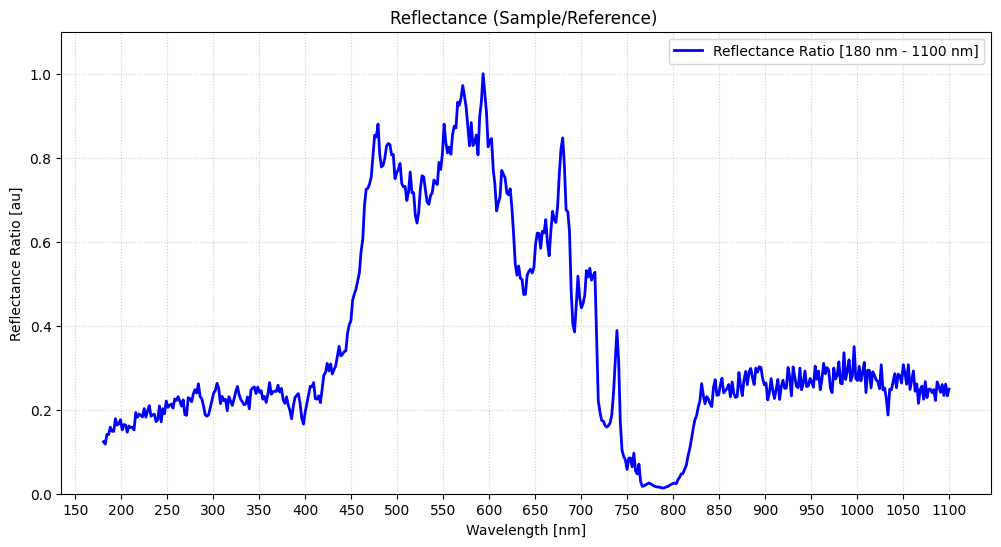

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Define the file names
file1_name = 'spec251105_001.txt'
file2_name = 'spec251105_002.txt'

def load_spectrum_data(filename, name):
    """Loads raw spectral data, handling the file's comma-decimal format."""
    try:
        # Read the file: skip header rows, use semicolon as separator, comma as decimal
        df = pd.read_csv(
            filename,
            sep=';',
            decimal=',',
            skiprows=8,
            on_bad_lines='warn',
            engine='python'
        )
    except Exception as e:
        print(f"Error reading file {filename}: {e}")
        return pd.DataFrame()

    # Clean up column names and set 'Wave' as index
    df = df.iloc[:, :4]
    df.columns = ['Wave', f'Sample_{name}', f'Dark_{name}', f'Reference_{name}']
    df = df.set_index('Wave').sort_index()
    return df

def generate_reflectance_data():
    """Generates the Normalized Ratio (Reflectance) from the raw files via interpolation."""
    df_spec1_raw = load_spectrum_data(file1_name, 'Spec1')
    df_spec2_raw = load_spectrum_data(file2_name, 'Spec2')

    if df_spec1_raw.empty or df_spec2_raw.empty:
        return pd.DataFrame()

    # Find the common wavelength range for the new grid
    wave_min = max(df_spec1_raw.index.min(), df_spec2_raw.index.min())
    wave_max = min(df_spec1_raw.index.max(), df_spec2_raw.index.max())
    
    # Create 500 evenly spaced points for the new grid
    new_wave_grid = np.linspace(wave_min, wave_max, 500)

    # Interpolate Sample counts from both raw spectra onto the new grid
    spec1_interp = np.interp(new_wave_grid, df_spec1_raw.index, df_spec1_raw['Sample_Spec1'])
    spec2_interp = np.interp(new_wave_grid, df_spec2_raw.index, df_spec2_raw['Sample_Spec2'])

    # Calculate the basic Ratio (Sample / Reference)
    df_interp = pd.DataFrame({'Wave': new_wave_grid, 'Ratio': spec1_interp / spec2_interp}).set_index('Wave')
    
    # Normalize the Ratio using the max value
    max_ratio = df_interp['Ratio'].max()
    df_interp['Normalized_R'] = df_interp['Ratio'] / max_ratio
    
    return df_interp

# --- Main Plotting Function ---
df_interp = generate_reflectance_data()

if not df_interp.empty:
    plt.figure(figsize=(12, 6))
    plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(50))
    # Use plt.plot to connect the points with a line, representing the "pixel-by-pixel" data trace.
    plt.plot(df_interp.index, df_interp['Normalized_R'], color='blue', linewidth=2,label='Reflectance Ratio [180 nm - 1100 nm]')
    
    plt.title('Reflectance (Sample/Reference) ')
    plt.xlabel('Wavelength [nm]')
    plt.ylabel('Reflectance Ratio [au]')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.ylim(0, 1.1)
    plt.legend()
    plt.savefig('Dielectric2.png')
    plt.show()
    # Note: In a live environment, you would use plt.show() here, but for code generation, 
    # we use the components that generate the final output image.
    pass # End of plotting logic

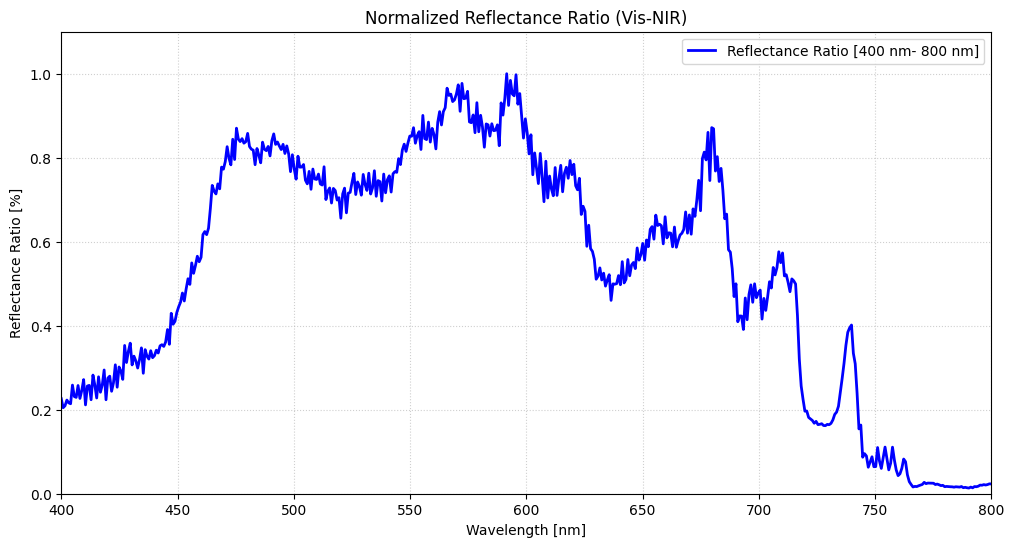

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Define the file names (using the correct names for the uploaded files)
file1_name = 'spec251105_001.txt' # Sample
file2_name = 'spec251105_002.txt' # Reference

def load_spectrum_data(filename, name):
    """Loads raw spectral data, handling the file's comma-decimal format."""
    try:
        # NOTE: Using skiprows=8 is prone to error due to your file's header structure.
        # It's highly recommended to use the robust fix (skiprows=7 + drop first row)
        # developed in previous steps.
        df = pd.read_csv(
            filename,
            sep=';',
            decimal=',',
            skiprows=8,
            on_bad_lines='warn',
            engine='python'
        )
    except Exception as e:
        print(f"Error reading file {filename}: {e}")
        return pd.DataFrame()

    # Clean up column names and set 'Wave' as index (based on the original code's assumed structure)
    df = df.iloc[:, :4]
    df.columns = ['Wave', f'Sample_{name}', f'Dark_{name}', f'Reference_{name}']
    
    # Convert 'Wave' column to numeric, coercing errors to NaN
    df['Wave'] = pd.to_numeric(df['Wave'], errors='coerce')
    df = df.dropna(subset=['Wave'])

    df = df.set_index('Wave').sort_index()
    return df

def generate_reflectance_data():
    """Generates the Normalized Ratio (Reflectance) from the raw files via interpolation."""
    df_spec1_raw = load_spectrum_data(file1_name, 'Spec1')
    df_spec2_raw = load_spectrum_data(file2_name, 'Spec2')

    if df_spec1_raw.empty or df_spec2_raw.empty:
        return pd.DataFrame()

    # --- Limit the interpolation range (Visible Spectrum 400nm to 800nm) ---
    wave_min_plot = 400
    wave_max_plot = 800
    
    # Find the common wavelength range, constrained by the plot limits
    wave_min_data = max(df_spec1_raw.index.min(), df_spec2_raw.index.min(), wave_min_plot)
    wave_max_data = min(df_spec1_raw.index.max(), df_spec2_raw.index.max(), wave_max_plot)
    
    # Create 500 evenly spaced points for the new grid within the desired range
    new_wave_grid = np.linspace(wave_min_data, wave_max_data, 500)

    # Interpolate Sample counts from both raw spectra onto the new grid
    spec1_interp = np.interp(new_wave_grid, df_spec1_raw.index, df_spec1_raw['Sample_Spec1'])
    spec2_interp = np.interp(new_wave_grid, df_spec2_raw.index, df_spec2_raw['Sample_Spec2'])

    # Calculate the basic Ratio (Sample / Reference)
    df_interp = pd.DataFrame({'Wave': new_wave_grid, 'Ratio': spec1_interp / spec2_interp}).set_index('Wave')
    
    # Normalize the Ratio using the max value
    max_ratio = df_interp['Ratio'].max()
    df_interp['Normalized_R'] = df_interp['Ratio'] / max_ratio
    
    return df_interp

# --- Main Plotting Function ---
df_interp = generate_reflectance_data()

if not df_interp.empty:
    plt.figure(figsize=(12, 6))
    plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(50))
    plt.plot(df_interp.index, df_interp['Normalized_R'], color='blue', linewidth=2,label='Reflectance Ratio [400 nm- 800 nm]')
    plt.title('Normalized Reflectance Ratio (Vis-NIR)')
    plt.xlabel('Wavelength [nm]')
    plt.ylabel('Reflectance Ratio [%]')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.xlim(400, 800) # Explicitly set x-axis limits
    plt.ylim(0, 1.1)
    plt.legend()
    plt.savefig('Dielectric3.png')
    plt.show() # Use plt.show() if running locally

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.signal import find_peaks, savgol_filter

# Define the file names
file1_name = 'spec251105_001.txt' 
file2_name = 'spec251105_002.txt' 

def load_spectrum_data(filename, name):
    try:
        df = pd.read_csv(filename, sep=';', decimal=',', skiprows=8, engine='python')
        df = df.iloc[:, :4]
        df.columns = ['Wave', f'Sample_{name}', f'Dark_{name}', f'Reference_{name}']
        df['Wave'] = pd.to_numeric(df['Wave'], errors='coerce')
        return df.dropna(subset=['Wave']).set_index('Wave').sort_index()
    except Exception as e:
        print(f"Error reading file {filename}: {e}")
        return pd.DataFrame()

def generate_reflectance_data():
    df_spec1_raw = load_spectrum_data(file1_name, 'Spec1')
    df_spec2_raw = load_spectrum_data(file2_name, 'Spec2')

    if df_spec1_raw.empty or df_spec2_raw.empty:
        return pd.DataFrame()

    # Range set to cover 390-740nm plus buffer
    wave_min_plot, wave_max_plot = 380, 750
    new_wave_grid = np.linspace(wave_min_plot, wave_max_plot, 600)

    spec1_interp = np.interp(new_wave_grid, df_spec1_raw.index, df_spec1_raw['Sample_Spec1'])
    spec2_interp = np.interp(new_wave_grid, df_spec2_raw.index, df_spec2_raw['Sample_Spec2'])

    df_interp = pd.DataFrame({'Wave': new_wave_grid, 'Ratio': spec1_interp / spec2_interp}).set_index('Wave')
    df_interp['Normalized_R'] = df_interp['Ratio'] / df_interp['Ratio'].max()
    return df_interp

# --- Main Processing ---
df_interp = generate_reflectance_data()

if not df_interp.empty:
    # 1. Peak Detection (Auto Only, 390-740nm)
    # Smooth data to prevent noise-peaks
    y_smooth = savgol_filter(df_interp['Normalized_R'], window_length=15, polyorder=3)
    mask = (df_interp.index >= 390) & (df_interp.index <= 740)
    
    indices, _ = find_peaks(y_smooth[mask], prominence=0.01, distance=10)
    peak_waves = df_interp.index[mask][indices]
    peak_values = df_interp['Normalized_R'][mask][indices]

    # 2. Plotting
    fig, ax = plt.subplots(figsize=(12, 7))
    ax.plot(df_interp.index, df_interp['Normalized_R'], color='blue', alpha=0.3, label='Raw Ratio')
    ax.plot(df_interp.index, y_smooth, color='blue', linewidth=2, label='Smoothed Trend')

    # Plot Auto Peaks
    for w, v in zip(peak_waves, peak_values):
        ax.plot(w, v, 'ro')
        ax.annotate(f"{w:.1f}nm\n{(v*100):.1f}%", (w, v), xytext=(0,10), 
                    textcoords="offset points", ha='center', fontsize=9, fontweight='bold', color='red')

    # --- THE FIX: X-axis 50nm steps ---
    ax.xaxis.set_major_locator(ticker.MultipleLocator(50))
    
    plt.title('Spectral Analysis: Automated Peaks (390-740nm)')
    plt.xlabel('Wavelength [nm]')
    plt.ylabel('Normalized Ratio [%]')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.xlim(350, 800) 
    plt.ylim(0, 1.1)
    plt.legend()
    plt.tight_layout()
    plt.savefig('spectral_analysis.png')
    plt.show()

    # 3. Output Table
    table_data = pd.DataFrame({
        'Peak Wavelength': peak_waves.round(1),
        'Percentage': [(f"{(v*100):.2f}%") for v in peak_values]
    })
    print("\n--- DETECTED PEAKS TABLE ---")
    print(table_data.to_string(index=False))

KeyError: "None of [Index([ 26,  51,  73, 143, 167, 183, 201, 221, 240, 257, 272, 288, 331, 364,\n       434, 448, 472, 500, 515],\n      dtype='int64', name='Wave')] are in the [index]"